In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
dataset = pd.read_excel("/content/home_price_dataset.xlsx")
dataset.head(5)

,Size_sqft,Bedrooms,Bathrooms,Location_Score,Price
0,883,4,2,4.42,228395
1,542,4,4,2.61,148637
2,3850,1,3,7.89,644315
3,1674,6,3,5.00,368979
4,3032,6,2,4.20,557254


In [ ]:
dataset.shape

(50, 5)

In [ ]:
dataset.describe()

,Size_sqft,Bedrooms,Bathrooms,Location_Score,Price
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,2530.980000,3.340000,2.560000,5.382800,460159.560000
std,1125.819475,1.611312,0.951047,2.546925,171824.073296
min,542.000000,1.000000,1.000000,1.050000,148637.000000
25%,1299.500000,2.000000,2.000000,3.380000,277791.750000
50%,2808.000000,3.000000,3.000000,4.710000,519400.000000
75%,3617.750000,4.000000,3.000000,7.630000,608647.500000
max,3905.000000,6.000000,4.000000,9.970000,719528.000000


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Size_sqft       50 non-null     int64  
 1   Bedrooms        50 non-null     int64  
 2   Bathrooms       50 non-null     int64  
 3   Location_Score  50 non-null     float64
 4   Price           50 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 2.1 KB


In [ ]:
dataset.isnull().sum()

,0
Size_sqft,0
Bedrooms,0
Bathrooms,0
Location_Score,0
Price,0


In [ ]:
dataset.notnull().sum()

,0
Size_sqft,50
Bedrooms,50
Bathrooms,50
Location_Score,50
Price,50


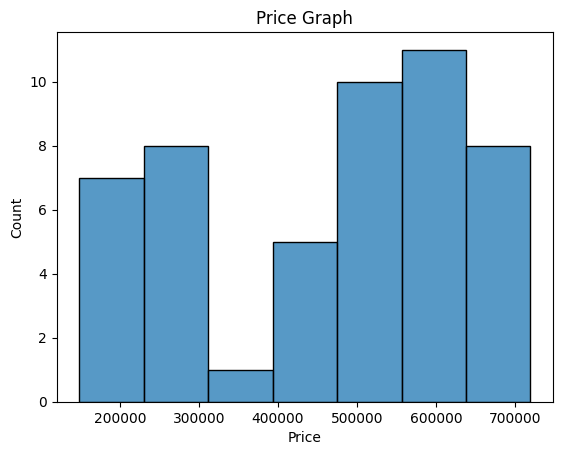

In [ ]:
sns.histplot(dataset["Price"])
plt.title("Price Graph")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x = dataset[["Bedrooms"]]
y = dataset["Price"]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_x = StandardScaler()
x_scaled = scaler_x.fit_transform(x)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y_scaled, test_size=0.2, random_state=42)

In [ ]:
print(f"Training samples: {x_train.shape[0]}")
print(f"Testing samples: {x_test.shape[0]}")

Training samples: 40
Testing samples: 10


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
print("intercept (b):", model.intercept_)
print("Coefficients (m):", model.coef_)

intercept (b): [-0.05360558]
Coefficients (m): [[0.00116136]]


In [ ]:
y_pred_scaled = model.predict(x_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_original = scaler_y.inverse_transform(y_test)

In [ ]:
print("Original Y Test Samples:", y_test_original[:5])
print("Predicted Y Samples:", y_pred[:5])

Original Y Test Samples: [[275752.]
 [561356.]
 [534124.]
 [528861.]
 [612207.]]
Predicted Y Samples: [[451123.1402214 ]
 [451123.1402214 ]
 [451246.98339483]
 [450999.29704797]
 [450999.29704797]]


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 17098928824.68
R-squared: -0.14
